In [1]:
import gdown
import zipfile
import os

# https://drive.google.com/file/d/1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55/view?usp=sharing

# Google Drive file ID (Extracted from the URL)
file_id = "1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55"

# Destination file name
output_zip = "pictures.zip"

# Downloading the file from Google Drive
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Extracting the zip file
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall("pictures")  # Extracting to 'Clips' folder

# Removing the zip file after extraction
os.remove(output_zip)

print("Download and extraction complete!")


Downloading...
From (original): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55
From (redirected): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55&confirm=t&uuid=6d5b7657-3cf0-454e-8715-71a9837977f2
To: /content/pictures.zip
100%|██████████| 108M/108M [00:01<00:00, 108MB/s]


Download and extraction complete!


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]


Epoch [1/40] Loss: 242.4826 | Train Acc: 28.76% | Val Acc: 66.67%
Epoch [2/40] Loss: 170.7863 | Train Acc: 41.59% | Val Acc: 50.00%
Epoch [3/40] Loss: 156.8369 | Train Acc: 45.13% | Val Acc: 50.00%
Epoch [4/40] Loss: 170.7165 | Train Acc: 43.81% | Val Acc: 50.00%
Epoch [5/40] Loss: 129.8116 | Train Acc: 50.00% | Val Acc: 75.00%
Epoch [6/40] Loss: 121.1626 | Train Acc: 54.42% | Val Acc: 66.67%
Epoch [7/40] Loss: 115.1171 | Train Acc: 58.41% | Val Acc: 41.67%
Epoch [8/40] Loss: 116.8031 | Train Acc: 56.64% | Val Acc: 66.67%
Epoch [9/40] Loss: 105.1724 | Train Acc: 65.49% | Val Acc: 66.67%
Epoch [10/40] Loss: 111.6474 | Train Acc: 63.27% | Val Acc: 66.67%
Epoch [11/40] Loss: 103.1666 | Train Acc: 62.39% | Val Acc: 50.00%
Epoch [12/40] Loss: 103.0638 | Train Acc: 61.95% | Val Acc: 33.33%
Epoch [13/40] Loss: 83.8175 | Train Acc: 69.91% | Val Acc: 50.00%
Epoch [14/40] Loss: 95.8764 | Train Acc: 67.70% | Val Acc: 58.33%
Epoch [15/40] Loss: 76.0201 | Train Acc: 74.34% | Val Acc: 50.00%
⏹️ Earl

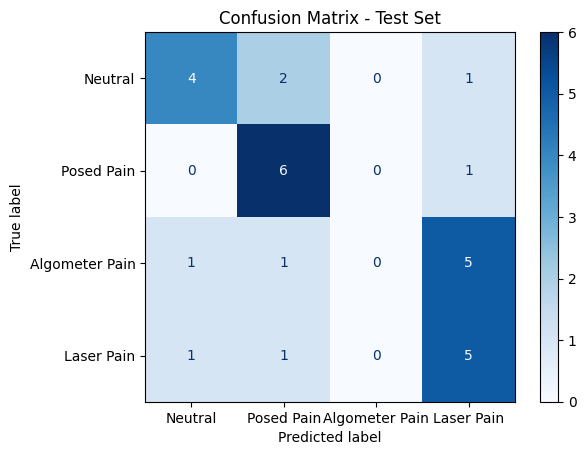

In [2]:


# -----------------------------
# CONFIG
# -----------------------------
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DATA_ROOT = "/content/pictures"
EXPR_LABELS = {'Neutral': 0, 'Posed Pain': 1, 'Algometer Pain': 2, 'Laser Pain': 3}
IDX_TO_LABEL = {v: k for k, v in EXPR_LABELS.items()}
IMG_SIZE = 224
SEQ_LEN = 20
BATCH_SIZE = 4
EPOCHS = 40
LR = 1e-4
PATIENCE = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# SUBJECT SPLITS (3-WAY)
# -----------------------------
train_subjects = [f"S{str(i).zfill(3)}" for i in range(1, 59)]     # S001–S058
val_subjects = [f"S{str(i).zfill(3)}" for i in range(59, 62)]       # S059–S061
test_subjects = [f"S{str(i).zfill(3)}" for i in range(62, 69)]      # S062–S068

# -----------------------------
# TRANSFORMS
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -----------------------------
# DATASET CLASS
# -----------------------------
class PainSequenceDataset(Dataset):
    def __init__(self, subject_ids, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for subject in subject_ids:
            subject_path = os.path.join(root_dir, subject)
            for expr, label in EXPR_LABELS.items():
                expr_path = os.path.join(subject_path, expr, "Colour frames")
                if os.path.exists(expr_path):
                    frame_files = sorted([
                        os.path.join(expr_path, f)
                        for f in os.listdir(expr_path) if f.endswith(".jpg")
                    ])
                    if len(frame_files) == SEQ_LEN:
                        self.samples.append((frame_files, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = [self.transform(Image.open(fp).convert('RGB')) for fp in frame_paths]
        clip_tensor = torch.stack(frames)  # (SEQ_LEN, 3, H, W)
        return clip_tensor, label

# -----------------------------
# POSITIONAL ENCODING
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=SEQ_LEN):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position.float() * div_term)
        pe[:, 1::2] = torch.cos(position.float() * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# -----------------------------
# FOCAL LOSS
# -----------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# -----------------------------
# MODEL
# -----------------------------
class CNNTransformer(nn.Module):
    def __init__(self, cnn_output_dim=1280, nhead=4, num_layers=1, num_classes=4):
        super().__init__()
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.cnn = mobilenet.features
        for i, block in enumerate(self.cnn.children()):
            if i < 5:  # Freeze early blocks
                for param in block.parameters():
                    param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.pos_encoding = PositionalEncoding(cnn_output_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=cnn_output_dim, nhead=nhead, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(cnn_output_dim, num_classes))

    def forward(self, x):
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = x.view(B, T, -1)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Mean Pooling
        return self.fc(x)

# -----------------------------
# LOADERS
# -----------------------------
train_dataset = PainSequenceDataset(train_subjects, DATA_ROOT, transform=train_transform)
val_dataset = PainSequenceDataset(val_subjects, DATA_ROOT, transform=val_transform)
test_dataset = PainSequenceDataset(test_subjects, DATA_ROOT, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# TRAINING
# -----------------------------
model = CNNTransformer().to(device)
criterion = FocalLoss(alpha=1, gamma=2)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

train_acc_history, val_acc_history = [], []
best_val_acc = 0
wait = 0
best_model_wts = None

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0
    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs = model(clips)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * clips.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_dataset)

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dataset)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")
    torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pth")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        best_model_wts = model.state_dict()
    else:
        wait += 1
        if wait >= PATIENCE:
            print("⏹️ Early stopping triggered.")
            break

if best_model_wts:
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "cnn_transformer_final.pth")
    print("✅ Best model saved to cnn_transformer_final.pth")

# -----------------------------
# PLOT TRAIN/VAL ACCURACY
# -----------------------------
# plt.plot(range(1, len(train_acc_history)+1), train_acc_history, label='Train Acc', marker='x')
# plt.plot(range(1, len(val_acc_history)+1), val_acc_history, label='Val Acc', marker='o')
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Train vs Validation Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()

# -----------------------------
# FINAL EVALUATION ON TEST SET
# -----------------------------
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for clips, labels in test_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs = model(clips)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc = sum([p == t for p, t in zip(all_preds, all_labels)]) / len(all_preds)
print(f"🧪 Final Test Accuracy (S062–S068): {acc*100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(EXPR_LABELS.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()
